# Synthetic Data Generation

Evaluate CTGAN and TVAE as synthetic data generators for the combined shelf-life dataset.

Key design choices:
- Derived columns (`initial_inhibition_factor`, `post_inhibition_factor`, `post_threshold_proximity_index_2(tpi)`) are **excluded from GAN training** and recomputed deterministically afterward.
- `experiment_id` and `ingredient_id` are **re-assigned after sampling** based on grouping keys, preserving logical structure.
- `data_source` is hard-coded to `"synthetic"` for all generated rows.
- `N_EXPERIMENTS` controls the size of the output (configurable at the top of Section 1).

## Table of Contents

1. [Setup and Imports](#1-setup-and-imports)
2. [Column Definitions](#2-column-definitions)
3. [Pre-processing for GAN](#3-pre-processing-for-gan)
4. [SDV Metadata](#4-sdv-metadata)
5. [Model Factory](#5-model-factory)
6. [Training Loop](#6-training-loop)
   - [6.1. Conditional Generation Helper](#61-conditional-generation-helper)
7. [Post-processing: Re-assign IDs & Recompute Derived Columns](#7-post-processing-re-assign-ids--recompute-derived-columns)
   - [7.1. Post-Generation Validation](#71-post-generation-validation)
   - [7.2. Final Output](#72-final-output)
8. [TSTR Evaluation](#8-tstr-evaluation)
9. [Results Summary](#9-results-summary)
10. [Statistical Fidelity Check](#10-statistical-fidelity-check)

## 1. Setup and Imports

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import ks_2samp
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer, TVAESynthesizer

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Configurable ─────────────────────────────────────────────────────────────
N_EXPERIMENTS = 1000   # number of unique synthetic experiment groups to produce
EPOCHS        = 300   # GAN training epochs
# ─────────────────────────────────────────────────────────────────────────────

ROOT          = Path("..").resolve()
DATA_DIR      = ROOT / "data"
SYNTHETIC_DIR = DATA_DIR / "synthetic"
SYNTHETIC_DIR.mkdir(parents=True, exist_ok=True)

df_raw = pd.read_csv(DATA_DIR / "processed" / "combined_shelf_life.csv")
print(f"Loaded: {df_raw.shape[0]} rows x {df_raw.shape[1]} cols")
df_raw.head(3)

## 2. Column Definitions

In [ ]:
# Columns whose values are deterministically derived from other columns.
# These are EXCLUDED from GAN training and recomputed after sampling.
DERIVED_COLS = [
    "normalized_concentration_%_of_meat",   # no formula available; left NaN
    "initial_inhibition_factor",
    "post_inhibition_factor",
    "post_threshold_proximity_index_2(tpi)",
    "gas_N2",   # always CO2+O2+N2≈100% in real data; reconstructed post-sampling, never trained on
]

ID_COLS = ["experiment_id", "ingredient_id"]

# Columns the GAN trains on (source columns only)
GAN_COLS = [
    c for c in df_raw.columns
    if c not in DERIVED_COLS + ID_COLS + ["data_source"]
]

# Categorical vs numerical split for SDV metadata and TSTR preprocessing
CAT_COLS = [c for c in GAN_COLS if df_raw[c].dtype == object]

# Threshold/target-derived columns are censored, not missing-at-random: a NaN here means
# the sample never crossed that threshold during the observation window, not that the
# measurement is unknown. These get a censored-state encoding (-1 + mask) in Section 3
# instead of median imputation, which would fabricate a crossing day/count that was never
# observed.
THRESHOLD_COLS = ["post_threshold_(day)", "post_threshold_count"]

NUM_COLS = [c for c in GAN_COLS if c not in CAT_COLS]

# Grouping key used to re-assign experiment_id after generation.
# Rows that share these values belong to the same synthetic experiment.
# Uses the decomposed hurdle axes (physical_hurdle_tech/application_method/hurdle_coordination)
# instead of the old flattened `treatment` string, which no longer exists in the schema.
EXPERIMENT_KEY = [
    "meat_type", "indicators", "storage_condition_(°c)",
    "physical_hurdle_tech", "application_method", "hurdle_coordination",
]

print(f"GAN training columns ({len(GAN_COLS)}): {GAN_COLS}")
print(f"\nCategorical ({len(CAT_COLS)}): {CAT_COLS}")
print(f"\nNumerical   ({len(NUM_COLS)}): {NUM_COLS}")
print(f"\nCensored/threshold ({len(THRESHOLD_COLS)}): {THRESHOLD_COLS}")

## 3. Pre-processing for GAN

Drop derived columns and IDs so the GAN never sees them. Then:

1. **Impute missing values** so CTGAN never trains on raw `NaN`:
   - Numerical (non-threshold): median impute + a binary `<col>_missing` indicator column.
   - Categorical: fill with a consistent `"__missing__"` category (no indicator needed —
     `"__missing__"` is itself an explicit level CTGAN can learn to reproduce).
   - Threshold columns (`post_threshold_(day)`, `post_threshold_count`): these are censored,
     not missing-at-random (`NaN` means "never crossed this threshold during observation",
     not "unknown"), so they're encoded as `-1` + a binary `<col>_censored` indicator instead
     of being handed a fabricated median day/count.
2. **Scale** every numerical value column (including the now-imputed threshold columns) with
   `MinMaxScaler`, fit once on the imputed training frame and reused later to inverse-transform
   generated samples back to the original scale (Section 7).
3. **Oversample** via `conditional_matrix_sample` to balance rare categorical configurations
   and post-threshold survivors before fitting.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

MISSING_CAT_TOKEN = "__missing__"
NUM_COLS_TO_IMPUTE = [c for c in NUM_COLS if c not in THRESHOLD_COLS]
MISSING_INDICATOR_COLS = [f"{c}_missing" for c in NUM_COLS_TO_IMPUTE]
CENSORED_INDICATOR_COLS = [f"{c}_censored" for c in THRESHOLD_COLS]
INDICATOR_COLS = MISSING_INDICATOR_COLS + CENSORED_INDICATOR_COLS


def impute_missing(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """
    Impute NaNs so the GAN never trains on raw missing values.

      - Categorical      -> fill with MISSING_CAT_TOKEN (an explicit, learnable category).
      - Numerical         -> median impute + <col>_missing binary indicator.
      - Threshold/target  -> censored, not MAR: fill with -1 + <col>_censored indicator
                              instead of a fabricated median (NaN here means "never
                              crossed this threshold", not "unknown value").

    Returns the imputed frame plus a dict of fitted impute values (medians) so the same
    values can be reused at inference/inverse-transform time if needed.
    """
    df = df.copy()
    impute_values: dict = {}

    for col in CAT_COLS:
        if col in df.columns:
            df[col] = df[col].fillna(MISSING_CAT_TOKEN)

    for col in NUM_COLS_TO_IMPUTE:
        if col not in df.columns:
            continue
        median = df[col].median()
        impute_values[col] = median
        df[f"{col}_missing"] = df[col].isna().astype(int)
        df[col] = df[col].fillna(median)

    for col in THRESHOLD_COLS:
        if col not in df.columns:
            continue
        df[f"{col}_censored"] = df[col].isna().astype(int)
        df[col] = df[col].fillna(-1)

    return df, impute_values


def scale_numeric(df: pd.DataFrame, num_cols: list[str]) -> tuple[pd.DataFrame, MinMaxScaler]:
    """Fit-transform NUM_COLS (value columns only, not the 0/1 indicator columns)."""
    df = df.copy()
    scaler = MinMaxScaler()
    cols = [c for c in num_cols if c in df.columns]
    df[cols] = scaler.fit_transform(df[cols])
    return df, scaler


def conditional_matrix_sample(
    df: pd.DataFrame,
    cat_cols: list[str],
    sparse_threshold: float = 0.02,
    has_post: np.ndarray | None = None,
    target_n: int | None = None,
    random_state: int = 42,
) -> pd.DataFrame:
    """
    has_post: precomputed boolean array marking rows that had real (pre-imputation)
    post-threshold data. Passed explicitly rather than derived from `df.notna()` inside
    this function, because by the time `df` reaches here the threshold columns have
    already been imputed (-1 + *_censored indicator) — notna() would be True for every
    row and the post-threshold-survivor oversampling weight would silently become a no-op.
    """
    rng = np.random.default_rng(random_state)
    target_n = target_n or len(df)

    col_weights = np.ones(len(df))
    for col in cat_cols:
        freq = df[col].fillna(MISSING_CAT_TOKEN).map(
            df[col].fillna(MISSING_CAT_TOKEN).value_counts(normalize=True)
        ).values
        col_weights *= 1.0 / (np.log1p(freq * len(df)))

    if has_post is None:
        has_post = np.zeros(len(df), dtype=bool)
    col_weights = np.where(has_post, col_weights * 2.0, col_weights)

    sparse_masks = {}
    for col in cat_cols:
        freq_map = df[col].fillna(MISSING_CAT_TOKEN).value_counts(normalize=True)
        sparse_cats = freq_map[freq_map < sparse_threshold].index.tolist()
        sparse_masks[col] = df[col].fillna(MISSING_CAT_TOKEN).isin(sparse_cats)

    n_sparse_rows = pd.DataFrame(sparse_masks).any(axis=1).sum()
    print(f"Rows touching at least one sparse category (<{sparse_threshold:.0%}): {n_sparse_rows}/{len(df)}")
    print(f"Rows with post-threshold data: {has_post.sum()}/{len(df)}")

    weights = col_weights / col_weights.sum()
    sampled_idx = rng.choice(len(df), size=target_n, replace=True, p=weights)
    return df.iloc[sampled_idx].reset_index(drop=True)


# Strip derived cols, IDs, and data_source → training frame.
# errors="ignore" because DERIVED_COLS lists gas_N2 for documentation purposes even though
# it no longer exists in df_raw (it was dropped upstream in data_processing.ipynb) — it's
# only ever a synthetic-side reconstructed column now.
df_gan_source = df_raw.drop(columns=DERIVED_COLS + ID_COLS + ["data_source"], errors="ignore")

POST_THRESHOLD_COLS = [c for c in THRESHOLD_COLS if c in df_gan_source.columns]

# Capture post-threshold survivorship from the RAW (pre-imputation) frame — this signal
# would be lost once impute_missing() fills those columns with -1.
HAS_POST = (
    df_gan_source[POST_THRESHOLD_COLS].notna().any(axis=1).values
    if POST_THRESHOLD_COLS
    else np.zeros(len(df_gan_source), dtype=bool)
)

# Impute (median + indicator / -1 + censored indicator / __missing__ category), then scale.
df_gan_imputed, IMPUTE_VALUES = impute_missing(df_gan_source)
df_gan_scaled, NUM_SCALER = scale_numeric(df_gan_imputed, NUM_COLS)

GAN_TRAIN_COLS = GAN_COLS + INDICATOR_COLS

df_gan = conditional_matrix_sample(
    df_gan_scaled,
    cat_cols=CAT_COLS,
    sparse_threshold=0.02,
    has_post=HAS_POST,
    target_n=len(df_gan_scaled),
    random_state=42,
)

print(f"\nGAN training frame: {df_gan.shape}")
print(f"Indicator columns added: {INDICATOR_COLS}")
print("Missing post_threshold_(day) (should be 0, now encoded via *_censored):",
      df_gan["post_threshold_(day)"].isna().sum(), "/", len(df_gan))
print("post_threshold_(day)_censored rate:", df_gan["post_threshold_(day)_censored"].mean().round(3))

## 4. SDV Metadata

`SingleTableMetadata` captures the role of every column (categorical, numerical)
and is shared by all synthesisers. `df_gan` now also contains the `*_missing` /
`*_censored` indicator columns added in Section 3 — these are declared `categorical`
(they're 0/1 flags, not continuous quantities) so CTGAN treats them as discrete modes
rather than fitting a mixture-of-Gaussians to a two-point distribution.
`CAT_COLS` and `NUM_COLS` are passed explicitly rather than relying solely on
auto-detection, so the categorical/numerical split used for sampling matches the
one used everywhere else in this notebook.

In [ ]:
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_gan)

# Explicitly declare all three axes rather than trusting auto-detection alone — this is
# the authoritative categorical/numerical split used everywhere else in this notebook
# (CAT_COLS / NUM_COLS from Section 2, INDICATOR_COLS from Section 3), so CTGAN's
# column-type assumptions can't drift from the rest of the pipeline.
for col in CAT_COLS:
    if col in df_gan.columns:
        metadata.update_column(col, sdtype="categorical")
for col in NUM_COLS:
    if col in df_gan.columns:
        metadata.update_column(col, sdtype="numerical")
for col in INDICATOR_COLS:
    if col in df_gan.columns:
        metadata.update_column(col, sdtype="categorical")

metadata.validate()
print("Metadata validated")
print(list(metadata.to_dict()["columns"].keys()))

## 5. Model Factory

Both synthesisers are built with three shared training improvements:

- **WGAN-GP** — `pac=1` disables PAC-GAN grouping so the gradient penalty is applied per individual sample.
- **TTUR** (Two Time-Scale Update Rule) — discriminator lr is set to 4× the generator lr (8e-4 vs 2e-4).
- **Spectral Normalization** — injected into every `nn.Linear` layer of the discriminator after fitting.

In [5]:
def _apply_spectral_norm(module: nn.Module) -> nn.Module:
    for name, child in list(module.named_children()):
        if isinstance(child, nn.Linear):
            setattr(module, name, nn.utils.spectral_norm(child))
        else:
            _apply_spectral_norm(child)
    return module


_original_ctgan_fit = CTGANSynthesizer.fit


def _ctgan_fit_with_sn(self, data):
    _original_ctgan_fit(self, data)
    if hasattr(self, '_model') and hasattr(self._model, '_discriminator'):
        _apply_spectral_norm(self._model._discriminator)


CTGANSynthesizer.fit = _ctgan_fit_with_sn  # type: ignore[method-assign]


def build_ctgan(metadata: SingleTableMetadata, epochs: int = 300) -> CTGANSynthesizer:
    return CTGANSynthesizer(
        metadata,
        epochs=epochs,
        generator_lr=2e-4,
        generator_decay=1e-6,
        discriminator_lr=8e-4,       # TTUR: 4x generator lr
        discriminator_decay=1e-6,
        discriminator_steps=5,       # WGAN convention: more critic steps
        pac=1,                       # pac=1 -> per-sample gradient penalty
        batch_size=500,
        verbose=True,
    )


def build_tvae(metadata: SingleTableMetadata, epochs: int = 300) -> TVAESynthesizer:
    return TVAESynthesizer(
        metadata,
        epochs=epochs,
        batch_size=500,
        lr=2e-4,
        l2scale=1e-5,
    )


print("Model factory ready.")

Model factory ready.


## 6. Training Loop

Each model is an independent experiment. The GAN trains on `df_gan` (source columns only,
no IDs, no derived columns). After fitting it generates enough rows to produce
`N_EXPERIMENTS` synthetic experiment groups (estimated from the real data's average
rows-per-experiment). Raw GAN output is saved to `data/synthetic/<model_name>_raw.csv`
before post-processing.

In [ ]:
avg_rows_per_experiment = len(df_raw) / df_raw["experiment_id"].nunique()
N_SYNTHETIC = int(round(N_EXPERIMENTS * avg_rows_per_experiment))
print(f"avg rows/experiment in real data: {avg_rows_per_experiment:.1f}")
print(f"Target synthetic rows: {N_SYNTHETIC} (= {N_EXPERIMENTS} experiments × {avg_rows_per_experiment:.1f})")

EXPERIMENTS = {
    "ctgan": build_ctgan(metadata, epochs=EPOCHS),
}

synthetic_raw: dict[str, pd.DataFrame] = {}

for name, synth in tqdm(EXPERIMENTS.items(), total=len(EXPERIMENTS), desc="Training experiments"):
    print(f"\n{'='*60}")
    print(f"  Training {name.upper()} ({EPOCHS} epochs)")
    print(f"{'='*60}")
    t0 = time.time()
    synth.fit(df_gan)
    print(f"  -> Fit complete in {(time.time() - t0) / 60:.1f} min")

    df_syn_raw = synth.sample(num_rows=N_SYNTHETIC)
    raw_path = SYNTHETIC_DIR / f"{name}_raw.csv"
    df_syn_raw.to_csv(raw_path, index=False)
    synthetic_raw[name] = df_syn_raw
    print(f"  -> Saved {N_SYNTHETIC} raw rows to {raw_path}")

print("\nAll experiments complete.")

avg rows/experiment in real data: 16.9
Target synthetic rows: 16912 (= 1000 experiments × 16.9)

  Training CTGAN (300 epochs)



  0%|          | 0/300 [00:00<?, ?it/s]


Gen. (+00.00) | Discrim. (+00.00):   0%|          | 0/300 [00:00<?, ?it/s]


Gen. (+02.43) | Discrim. (-00.21):   0%|          | 0/300 [00:00<?, ?it/s]


Gen. (+02.43) | Discrim. (-00.21):   0%|          | 1/300 [00:00<02:57,  1.69it/s]

...


Gen. (+01.11) | Discrim. (-02.06): 100%|█████████▉| 299/300 [01:58<00:00,  3.00it/s]


Gen. (+01.11) | Discrim. (-02.06): 100%|██████████| 300/300 [01:58<00:00,  3.01it/s]


Gen. (+01.11) | Discrim. (-02.06): 100%|██████████| 300/300 [01:58<00:00,  2.53it/s]

  -> Fit complete in 2.2 min


  -> Saved 16912 raw rows to C:\Users\safae\projects\ML\data\synthetic\ctgan_raw.csv

All experiments complete.


### 6.1. Conditional Generation Helper

`generate_conditional_synthetic` is a reusable utility for sampling rows conditioned on
fixed categorical values (e.g. "give me more `meat_type=shrimp` rows" or "more `MAP`
packaging rows" to balance an under-represented slice). It is not wired into the main
training loop above — that loop calls plain `.sample(num_rows=...)` to preserve the
existing unconditional generation behavior. The helper is available for targeted
re-generation whenever a specific slice needs topping up.

Conditioning is attempted via SDV's native `sample_from_conditions` first (exact,
GAN-internal conditioning for CTGAN). If that raises for any of the requested columns
(CTGAN's conditional support varies by column/version), it falls back to reject sampling:
oversample unconditionally, filter to rows matching `conditions`, and repeat until either
`n_rows` is reached or `max_tries` batches are exhausted.

In [7]:
from sdv.sampling import Condition


def _matches_conditions(df: pd.DataFrame, conditions: dict) -> pd.Series:
    mask = pd.Series(True, index=df.index)
    for col, val in conditions.items():
        if col not in df.columns:
            continue
        mask &= df[col].isna() if pd.isna(val) else (df[col] == val)
    return mask


def generate_conditional_synthetic(
    synth,
    n_rows: int,
    conditions: dict,
    max_tries: int = 10,
    oversample_factor: int = 5,
) -> pd.DataFrame:
    """Sample n_rows from a fitted synthesizer, conditioned on fixed categorical values."""
    non_null_conditions = {k: v for k, v in conditions.items() if not pd.isna(v)}

    if non_null_conditions:
        try:
            condition_obj = Condition(num_rows=n_rows, column_values=non_null_conditions)
            return synth.sample_from_conditions(conditions=[condition_obj])
        except Exception as exc:
            print(f"Native conditional sampling unavailable ({exc}); falling back to reject sampling.")

    # Reject-sampling fallback: oversample, filter, repeat.
    collected = []
    collected_n = 0
    for _ in range(max_tries):
        batch = synth.sample(num_rows=n_rows * oversample_factor)
        matched = batch[_matches_conditions(batch, conditions)]
        collected.append(matched)
        collected_n += len(matched)
        if collected_n >= n_rows:
            break

    result = pd.concat(collected, ignore_index=True) if collected else pd.DataFrame(columns=GAN_COLS)
    return result.head(n_rows)


print("generate_conditional_synthetic ready.")

generate_conditional_synthetic ready.


## 7. Post-processing: Re-assign IDs & Recompute Derived Columns

Four steps applied to every raw GAN output before saving the final file:

1. **Inverse-transform numerical features** — GAN output for `NUM_COLS` is on the
   `MinMaxScaler`-fitted [0, 1] scale (Section 3); apply `NUM_SCALER.inverse_transform`
   to bring every numerical column back to its original units before anything downstream
   (derived-column formulas, validation, clipping) touches it.
2. **Drop indicator columns** — `*_missing` / `*_censored` were training-only artifacts
   that let CTGAN learn the real data's missingness pattern; per the notebook's own
   design goal (generate as much non-null data as possible), the generated numeric values
   are kept as-is and the indicator columns are dropped rather than used to re-mask
   values back to `NaN`.
3. **Re-assign `experiment_id`** — rows sharing the same `EXPERIMENT_KEY` values
   (meat_type, indicators, storage condition, treatment) receive the same sequential
   integer ID, starting from the next integer after the real data's maximum.
   **Re-assign `ingredient_id`** — within each synthetic experiment, each unique
   `ingredient` gets a distinct sequential integer (1, 2, 3 …).
4. **Recompute derived columns** — `initial_inhibition_factor`, `post_inhibition_factor`,
   and `post_threshold_proximity_index_2(tpi)` are computed from the GAN-generated
   (now inverse-transformed) source columns using the same formulas as
   `data_processing.ipynb`. `normalized_concentration_%_of_meat` has no available formula
   and is left `NaN`. `data_source` is set to `"synthetic"` for every row.

In [ ]:
def inverse_transform_numeric(df: pd.DataFrame) -> pd.DataFrame:
    """Undo the Section-3 MinMaxScaler so GAN output is back on its original scale."""
    df = df.copy()
    cols = [c for c in NUM_COLS if c in df.columns]
    df[cols] = NUM_SCALER.inverse_transform(df[cols])
    return df


def compute_inhibition_features(df: pd.DataFrame) -> pd.DataFrame:
    """Recompute derived columns from GAN source columns (mirrors data_processing.ipynb)."""
    return df.assign(
        initial_inhibition_factor=(
            (df["pre_threshold_count"] - df["initial_count_(day_0)"]) /
            df["pre_threshold_(day)"].replace(0, pd.NA)
        ),
        post_inhibition_factor=(
            (df["post_threshold_count"] - df["pre_threshold_count"]) /
            (df["post_threshold_(day)"] - df["pre_threshold_(day)"]).clip(lower=1e-6)
        ),
        **{"post_threshold_proximity_index_2(tpi)": (
            df["post_threshold_count"] /
            df["lower_level_threshold_(log_cfu/g)"].replace(0, pd.NA)
        )},
    )


def assign_ids(df: pd.DataFrame, experiment_id_offset: int = 0) -> pd.DataFrame:
    """
    Assign sequential experiment_id and ingredient_id to a synthetic dataframe.

    experiment_id  — one integer per unique combination of EXPERIMENT_KEY columns.
    ingredient_id  — within each experiment, one integer per unique ingredient value.
    """
    df = df.copy()

    # Fill NaN in key columns with a sentinel so groupby works cleanly
    key_filled = df[EXPERIMENT_KEY].fillna("__missing__")
    exp_map = {
        combo: i + 1 + experiment_id_offset
        for i, combo in enumerate(key_filled.drop_duplicates().itertuples(index=False, name=None))
    }
    df["experiment_id"] = key_filled.apply(lambda row: exp_map[tuple(row)], axis=1)

    # ingredient_id within each experiment
    ingredient_ids = []
    for exp_id, group in df.groupby("experiment_id", sort=False):
        ing_map: dict = {}
        counter = 1
        ids = []
        for ing in group["ingredient"].fillna("__missing__"):
            if ing not in ing_map:
                ing_map[ing] = counter
                counter += 1
            ids.append(ing_map[ing])
        ingredient_ids.extend(ids)
    df["ingredient_id"] = ingredient_ids

    return df


def postprocess(df_syn: pd.DataFrame) -> pd.DataFrame:
    """Full post-processing pipeline for a raw GAN sample."""
    df = df_syn.copy()

    # Step 1: undo scaling — every downstream computation expects original units
    df = inverse_transform_numeric(df)

    # Step 2: drop training-only indicator columns (kept generated values, per design
    # goal of maximizing non-null synthetic data rather than re-introducing NaNs)
    df = df.drop(columns=[c for c in INDICATOR_COLS if c in df.columns])

    # Step 3: IDs — offset from real data max so they never collide
    exp_offset = int(df_raw["experiment_id"].max())
    df = assign_ids(df, experiment_id_offset=exp_offset)

    # Step 4: recompute derived columns
    df = compute_inhibition_features(df)
    df["normalized_concentration_%_of_meat"] = np.nan  # no formula available

    # label
    df["data_source"] = "synthetic"

    # Reorder to match real data schema exactly
    df = df.reindex(columns=df_raw.columns)
    return df


# Apply post-processing to every raw GAN output
synthetic_datasets: dict[str, pd.DataFrame] = {}

for name, df_syn_raw in synthetic_raw.items():
    df_syn = postprocess(df_syn_raw)
    out_path = SYNTHETIC_DIR / f"{name}.csv"
    df_syn.to_csv(out_path, index=False)
    synthetic_datasets[name] = df_syn
    print(f"{name}: {df_syn.shape[0]} rows saved to {out_path}")
    print(f"  experiment_id range : {df_syn['experiment_id'].min()} – {df_syn['experiment_id'].max()}")
    print(f"  unique experiment_id: {df_syn['experiment_id'].nunique()}")
    print(f"  data_source values  : {df_syn['data_source'].unique()}")
    print(f"  sample derived values:")
    sample = df_syn[["initial_inhibition_factor", "post_inhibition_factor",
                     "post_threshold_proximity_index_2(tpi)"]].head(3)
    print(sample.to_string(index=False))

## 7.1. Post-Generation Validation

Four checks applied to the post-processed synthetic frame, in order:

1. **Gas reconstruction + conservation** — `gas_N2 = 100 - gas_CO2 - gas_O2` wherever both
   CO2 and O2 are present (only meaningful for `packaging_class == "map"`, since that's the
   only condition under which the real data ever records gas composition). A row is rejected
   if the reconstructed `gas_CO2 + gas_O2 + gas_N2` falls outside `99.5–100.5` — note this
   applies to the full reconstructed triple, not `CO2 + O2` alone: real data shows `CO2 + O2`
   is *not* ~100 (e.g. 65% CO2 + 5% O2, with N2 making up the rest), only the full triple
   conserves to 100%.
2. **Logical consistency** — each rule is a small predicate function registered in a list,
   so new rules can be added without touching the orchestrator. Two rules are hard-rejected
   because they are directly evidenced by the real data:
   - `hurdle_coordination == "Hybrid_Simultaneous"` with both `physical_hurdle_tech` and
     `application_method` empty (the coordination axis claims multiple hurdles were applied,
     but neither hurdle column says what they were).
   - `meat_type == "shrimp"` with any non-NaN packaging column (the real shrimp protocol
     never records packaging — confirmed structurally above).
   A third check — co-occurrence novelty — is **reported, not rejected**, by default: the set
   of `(packaging_class, packaging_material, container_type)` and
   `(physical_hurdle_tech, application_method, hurdle_coordination)` tuples seen in the real
   data is used as a discovered whitelist, and synthetic rows with an unseen tuple are counted
   but kept (CTGAN's value partly comes from interpolating between observed combinations, so
   hard-rejecting every novel tuple would defeat that). Set `STRICT_NOVELTY = True` below to
   reject novel tuples too.
3. **Clipping** — every numerical column in `NUM_COLS` is clipped to the real data's
   1st–99th percentile range.
4. **Reporting** — prints total generated, retained, rejected, and a per-rule rejection
   breakdown, then re-runs the two hard rules on the retained set and asserts zero violations
   remain.

In [9]:
STRICT_NOVELTY = False  # if True, also reject combinations never seen in real data
GAS_SUM_LOW, GAS_SUM_HIGH = 99.5, 100.5
PACKAGING_TUPLE_COLS = ["packaging_class", "packaging_material", "container_type"]
HURDLE_TUPLE_COLS = ["physical_hurdle_tech", "application_method", "hurdle_coordination"]


def reconstruct_and_validate_gas(df: pd.DataFrame) -> pd.DataFrame:
    """gas_N2 = 100 - CO2 - O2 where both are present; flag conservation violations."""
    df = df.copy()
    has_both = df["gas_CO2"].notna() & df["gas_O2"].notna()

    df["gas_N2"] = np.nan
    df.loc[has_both, "gas_N2"] = 100 - df.loc[has_both, "gas_CO2"] - df.loc[has_both, "gas_O2"]

    gas_total = df["gas_CO2"].fillna(0) + df["gas_O2"].fillna(0) + df["gas_N2"].fillna(0)
    violates_conservation = has_both & ~gas_total.between(GAS_SUM_LOW, GAS_SUM_HIGH)

    # Move gas_N2 next to gas_O2 to match the real-data column order
    cols = df.columns.tolist()
    cols.remove("gas_N2")
    cols.insert(cols.index("gas_O2") + 1, "gas_N2")
    return df[cols], violates_conservation


def rule_hybrid_without_hurdle(df: pd.DataFrame) -> pd.Series:
    """hurdle_coordination claims multiple hurdles but neither axis names one."""
    return (
        (df["hurdle_coordination"] == "hybrid_simultaneous")
        & df["physical_hurdle_tech"].isna()
        & df["application_method"].isna()
    )


def rule_shrimp_with_packaging(df: pd.DataFrame) -> pd.Series:
    """Real shrimp protocol never records packaging — any non-NaN packaging col is invalid."""
    packaging_cols = [c for c in ["packaging_class", "packaging_material", "container_type",
                                   "gas_CO2", "gas_O2", "gas_N2", "special_properties"]
                       if c in df.columns]
    return (df["meat_type"] == "shrimp") & df[packaging_cols].notna().any(axis=1)


HARD_REJECT_RULES = {
    "hybrid_coordination_without_hurdle": rule_hybrid_without_hurdle,
    "shrimp_with_packaging": rule_shrimp_with_packaging,
}


def discovered_whitelist(df_real: pd.DataFrame, tuple_cols: list[str]) -> set:
    """Observed combinations of tuple_cols in the real data — the data-driven novelty check."""
    cols = [c for c in tuple_cols if c in df_real.columns]
    return set(df_real[cols].fillna("__missing__").drop_duplicates().itertuples(index=False, name=None))


def flag_novel_combinations(df: pd.DataFrame, df_real: pd.DataFrame, tuple_cols: list[str]) -> pd.Series:
    cols = [c for c in tuple_cols if c in df.columns]
    whitelist = discovered_whitelist(df_real, tuple_cols)
    tuples = df[cols].fillna("__missing__").apply(tuple, axis=1)
    return ~tuples.isin(whitelist)


def clip_to_realistic_bounds(df: pd.DataFrame, df_real: pd.DataFrame, num_cols: list[str]) -> pd.DataFrame:
    df = df.copy()
    for col in num_cols:
        if col not in df.columns or col not in df_real.columns:
            continue
        lo, hi = df_real[col].quantile([0.01, 0.99])
        df[col] = df[col].clip(lower=lo, upper=hi)
    return df


def validate_synthetic(df_syn: pd.DataFrame, df_real: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """Full validation pipeline: gas reconstruction, hard rejection, novelty report, clipping."""
    n_generated = len(df_syn)
    df = df_syn.copy()

    df, gas_violation = reconstruct_and_validate_gas(df)

    rejection_masks = {"gas_conservation": gas_violation}
    for rule_name, rule_fn in HARD_REJECT_RULES.items():
        rejection_masks[rule_name] = rule_fn(df)

    packaging_novel = flag_novel_combinations(df, df_real, PACKAGING_TUPLE_COLS)
    hurdle_novel = flag_novel_combinations(df, df_real, HURDLE_TUPLE_COLS)
    novel_combo = packaging_novel | hurdle_novel
    if STRICT_NOVELTY:
        rejection_masks["novel_combination"] = novel_combo

    reject_mask = pd.Series(False, index=df.index)
    for mask in rejection_masks.values():
        reject_mask |= mask

    df_retained = df.loc[~reject_mask].reset_index(drop=True)
    df_retained = clip_to_realistic_bounds(df_retained, df_real, NUM_COLS)

    report = {
        "n_generated": n_generated,
        "n_retained": len(df_retained),
        "n_rejected": int(reject_mask.sum()),
        "rejection_counts": {name: int(mask.sum()) for name, mask in rejection_masks.items()},
        "novel_combination_count": int(novel_combo.sum()),  # always reported, even if not rejected
    }
    return df_retained, report


def validation_report(report: dict) -> None:
    print(f"Generated: {report['n_generated']}")
    print(f"Retained:  {report['n_retained']} ({report['n_retained'] / report['n_generated']:.1%})")
    print(f"Rejected:  {report['n_rejected']} ({report['n_rejected'] / report['n_generated']:.1%})")
    print("\nRejection breakdown:")
    for rule_name, count in report["rejection_counts"].items():
        print(f"  {rule_name:<35} {count:>6}  ({count / report['n_generated']:.1%})")
    print(f"\nNovel (unseen-in-real) combinations observed: {report['novel_combination_count']} "
          f"({report['novel_combination_count'] / report['n_generated']:.1%})"
          f"{' — rejected (STRICT_NOVELTY=True)' if STRICT_NOVELTY else ' — reported only, not rejected'}")


validated_datasets: dict[str, pd.DataFrame] = {}

for name, df_syn in synthetic_datasets.items():
    print(f"\n{'='*60}\n  Validating {name.upper()}\n{'='*60}")
    df_valid, report = validate_synthetic(df_syn, df_raw)
    validation_report(report)
    validated_datasets[name] = df_valid

    # Sanity check: zero hard-rule violations remain in the retained set
    remaining_violations = {
        rule_name: int(rule_fn(df_valid).sum())
        for rule_name, rule_fn in HARD_REJECT_RULES.items()
    }
    assert all(v == 0 for v in remaining_violations.values()), (
        f"Hard-rule violations survived validation: {remaining_violations}"
    )
    print("\nSanity check passed: zero hard-rule violations in retained set.")


  Validating CTGAN
Generated: 16912
Retained:  14803 (87.5%)
Rejected:  2109 (12.5%)

Rejection breakdown:
  gas_conservation                         0  (0.0%)
  hybrid_coordination_without_hurdle    1143  (6.8%)
  shrimp_with_packaging                 1018  (6.0%)

Novel (unseen-in-real) combinations observed: 15802 (93.4%) — reported only, not rejected

Sanity check passed: zero hard-rule violations in retained set.


### 7.2. Final Output

Concatenate the validated, clipped, gas-reconstructed output of every model into a single
file. This is additive — the per-model raw (`<name>_raw.csv`) and post-processed
(`<name>.csv`) files from Section 7 are kept as-is for debugging; `validated_datasets`
(used by this cell) is what feeds the final deliverable.

In [10]:
synthetic_data_final = pd.concat(validated_datasets.values(), ignore_index=True)

final_path = SYNTHETIC_DIR / "synthetic_data_final.csv"
synthetic_data_final.to_csv(final_path, index=False)
print(f"Saved {len(synthetic_data_final):,} validated rows to {final_path}")

Saved 14,803 validated rows to C:\Users\safae\projects\ML\data\synthetic\synthetic_data_final.csv


## 8. TSTR Evaluation

**Train on Synthetic, Test on Real** protocol.

Target: `post_threshold_proximity_index_2(tpi)` — a continuous score capturing how far a
preservation outcome has crossed the upper safety threshold.

- **Baseline** — trained on real data, tested on a fixed 20% real hold-out.
- **CTGAN / TVAE** — trained on the corresponding synthetic dataset, tested on the same hold-out.

Metrics: RMSE, MAE, R².

In [11]:
TARGET = "post_threshold_proximity_index_2(tpi)"

DROP_COLS    = ID_COLS + DERIVED_COLS + ["data_source"]
FEATURE_COLS = [c for c in df_raw.columns if c not in DROP_COLS]
CAT_FEATURES = [c for c in FEATURE_COLS if df_raw[c].dtype == object]
NUM_FEATURES = [c for c in FEATURE_COLS if c not in CAT_FEATURES]


def make_pipeline() -> Pipeline:
    pre = ColumnTransformer([
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), CAT_FEATURES),
        ("num", "passthrough", NUM_FEATURES),
    ])
    model = HistGradientBoostingRegressor(
        max_iter=400, learning_rate=0.05, max_depth=6, random_state=42,
    )
    return Pipeline([("pre", pre), ("model", model)])


def evaluate(pipe: Pipeline, X_test: pd.DataFrame, y_test: pd.Series) -> dict:
    y_pred = pipe.predict(X_test)
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_test, y_pred))),
        "MAE":  float(mean_absolute_error(y_test, y_pred)),
        "R2":   float(r2_score(y_test, y_pred)),
    }


def prepare_split(df: pd.DataFrame):
    d = df.dropna(subset=[TARGET]).copy()
    available_features = [c for c in FEATURE_COLS if c in d.columns]
    return d[available_features], d[TARGET]


# Fixed real 80/20 split — identical across all experiments
X_real, y_real = prepare_split(df_raw)
X_train_real, X_test, y_train_real, y_test = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42,
)

results: dict[str, dict] = {}

pipe_real = make_pipeline()
pipe_real.fit(X_train_real, y_train_real)
results["real (baseline)"] = evaluate(pipe_real, X_test, y_test)
print("Baseline (real -> real):", results["real (baseline)"])

for name, df_syn in synthetic_datasets.items():
    X_syn, y_syn = prepare_split(df_syn)
    if len(X_syn) == 0:
        print(f"{name.upper()}: no rows with target value after post-processing — skipping")
        continue
    pipe_syn = make_pipeline()
    pipe_syn.fit(X_syn, y_syn)
    results[name] = evaluate(pipe_syn, X_test, y_test)
    print(f"{name.upper()} (syn -> real):", results[name])

Baseline (real -> real): {'RMSE': 0.1679243538173612, 'MAE': 0.09045414595904483, 'R2': 0.9342127595313942}


CTGAN (syn -> real): {'RMSE': 1.6198623176496025, 'MAE': 0.9391500080040921, 'R2': -5.121678303384606}


## 9. Results Summary

In [12]:
baseline_rmse = results["real (baseline)"]["RMSE"]

df_results = (
    pd.DataFrame(results).T
    .rename_axis("experiment")
    .reset_index()
)
df_results["RMSE_vs_baseline_%"] = (
    (df_results["RMSE"] - baseline_rmse) / baseline_rmse * 100
).round(1)
df_results = df_results.sort_values("RMSE").round(4)

print("\n=== TSTR Results (sorted by RMSE) ===")
print(df_results.to_string(index=False))

df_results.to_csv(SYNTHETIC_DIR / "tstr_results.csv", index=False)
print(f"\nSaved to {SYNTHETIC_DIR / 'tstr_results.csv'}")


=== TSTR Results (sorted by RMSE) ===
     experiment   RMSE    MAE      R2  RMSE_vs_baseline_%
real (baseline) 0.1679 0.0905  0.9342                 0.0
          ctgan 1.6199 0.9392 -5.1217               864.6

Saved to C:\Users\safae\projects\ML\data\synthetic\tstr_results.csv


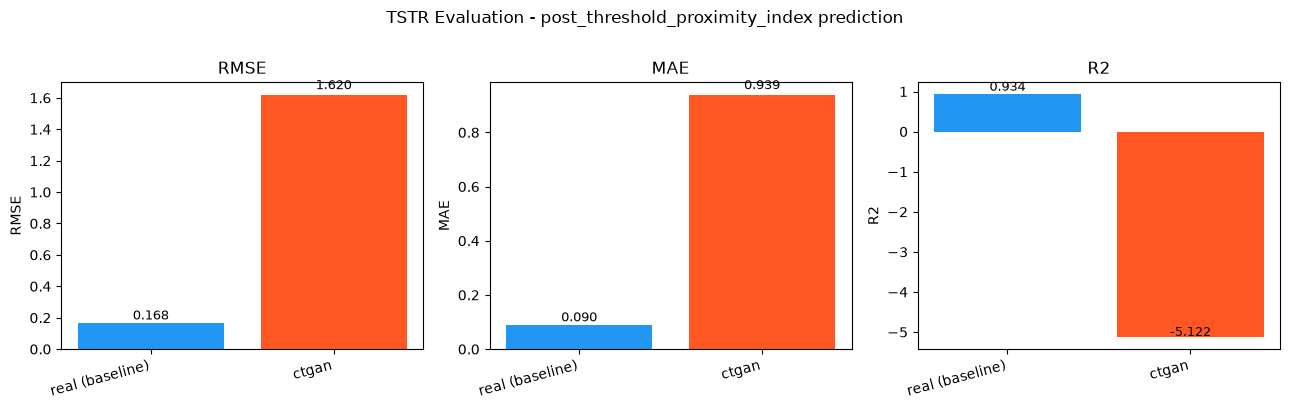

Plot saved.


In [13]:
metrics = ["RMSE", "MAE", "R2"]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ["#2196F3", "#FF5722", "#4CAF50"]

for ax, metric in zip(axes, metrics):
    bars = ax.bar(df_results["experiment"], df_results[metric], color=colors)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_xticklabels(df_results["experiment"], rotation=15, ha="right")
    for bar, val in zip(bars, df_results[metric]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=9,
        )

fig.suptitle(
    "TSTR Evaluation - post_threshold_proximity_index prediction",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.savefig(SYNTHETIC_DIR / "tstr_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

## 10. Statistical Fidelity Check

Column-wise KS statistics between real and synthetic numerical distributions.
Lower values indicate better marginal fidelity, independently of predictive utility.

In [14]:
def ks_fidelity(df_real: pd.DataFrame, df_syn: pd.DataFrame) -> pd.Series:
    stats = {}
    for col in NUM_COLS:   # GAN numerical columns (source columns only)
        if col not in df_syn.columns:
            continue
        r = df_real[col].dropna()
        s = df_syn[col].dropna()
        if len(r) < 2 or len(s) < 2:
            continue
        stat, _ = ks_2samp(r, s)
        stats[col] = round(stat, 4)
    return pd.Series(stats, name="KS statistic")


ks_rows = {name: ks_fidelity(df_raw, df_syn) for name, df_syn in synthetic_datasets.items()}
df_ks = pd.DataFrame(ks_rows)
df_ks.loc["mean"] = df_ks.mean()

print("=== KS Statistics (lower = better) ===")
print(df_ks.to_string())
df_ks.to_csv(SYNTHETIC_DIR / "ks_fidelity.csv")
print(f"\nSaved to {SYNTHETIC_DIR / 'ks_fidelity.csv'}")

=== KS Statistics (lower = better) ===
                                      ctgan
concentration                      0.229000
immersion_time                     0.845600
gas_CO2                            0.953500
gas_O2                             0.000000
irradiation_dose                   0.356300
lower_level_threshold_(log_cfu/g)  0.459200
upper_level_threshold_(log_cfu/g)  0.437500
initial_count_(day_0)              0.158800
pre_threshold_(day)                0.296300
pre_threshold_count                0.274600
post_threshold_(day)               0.545500
post_threshold_count               0.403100
mean                               0.413283

Saved to C:\Users\safae\projects\ML\data\synthetic\ks_fidelity.csv
